# Precision Multi-Class Irrigation Intelligence
**Project:** Predict irrigation need (Low / Medium / High) for crop fields  
**Dataset:** 630,000 rows · 19 features · Multi-class classification  
**Challenge:** Severe class imbalance (~17:1 Low vs High)

---
## Table of Contents
1. Setup & Imports
2. Data Loading & Overview
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Feature Engineering
5. Handling Class Imbalance
6. Model Training & Comparison
7. Evaluation & Interpretation
8. Lab Deliverables

---
## 1. Setup & Imports

In [1]:
# Install required libraries (run once)
# !pip install catboost lightgbm xgboost imbalanced-learn shap optuna scikit-learn pandas matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    cohen_kappa_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

# Interpretability
import shap

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = {'Low': '#378ADD', 'Medium': '#EF9F27', 'High': '#E24B4A'}

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Data Loading & Overview

In [2]:
# Load dataset
df = pd.read_csv('irrigation_needs.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns ({len(df.columns)}):')  
print(list(df.columns))
df.head(3)

Shape: (630000, 21)

Columns (21):
['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low


In [3]:
# Data types and null check
print('=== Data Types & Null Counts ===')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'nunique': df.nunique()
})
print(info_df.to_string())

=== Data Types & Null Counts ===
                           dtype  null_count  null_%  nunique
id                         int64           0     0.0   630000
Soil_Type                 object           0     0.0        4
Soil_pH                  float64           0     0.0      341
Soil_Moisture            float64           0     0.0     5223
Organic_Carbon           float64           0     0.0      131
Electrical_Conductivity  float64           0     0.0      341
Temperature_C            float64           0     0.0     2934
Humidity                 float64           0     0.0     6475
Rainfall_mm              float64           0     0.0    19308
Sunlight_Hours           float64           0     0.0      701
Wind_Speed_kmh           float64           0     0.0     1935
Crop_Type                 object           0     0.0        6
Crop_Growth_Stage         object           0     0.0        4
Season                    object           0     0.0        3
Irrigation_Type           object     

In [4]:
# Basic statistics for numeric columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.50,181865.48,0.00,157499.75,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.48,0.92,4.80,5.69,6.44,7.27,8.20
Soil_Moisture,630000.0,37.30,16.38,8.00,23.34,37.75,51.27,64.99
Organic_Carbon,630000.0,0.92,0.37,0.30,0.61,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.74,0.95,0.10,0.93,1.74,2.58,3.50
Temperature_C,630000.0,27.00,8.62,12.00,19.52,26.96,34.54,42.00
Humidity,630000.0,61.56,19.71,25.00,45.39,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.21,612.99,0.38,954.57,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.51,2.00,4.00,5.76,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.38,5.69,0.50,5.28,10.48,15.43,20.00


In [5]:
# Identify feature types
TARGET = 'Irrigation_Need'
DROP_COLS = ['id']

CAT_FEATURES = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
                'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

NUM_FEATURES = [c for c in df.columns
                if c not in CAT_FEATURES + [TARGET] + DROP_COLS]

print(f'Target: {TARGET}')
print(f'Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}')
print(f'Numerical features ({len(NUM_FEATURES)}): {NUM_FEATURES}')
print(f'Total input features: {len(CAT_FEATURES) + len(NUM_FEATURES)}')

Target: Irrigation_Need
Categorical features (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Numerical features (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Total input features: 19


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution — Deliverable 1

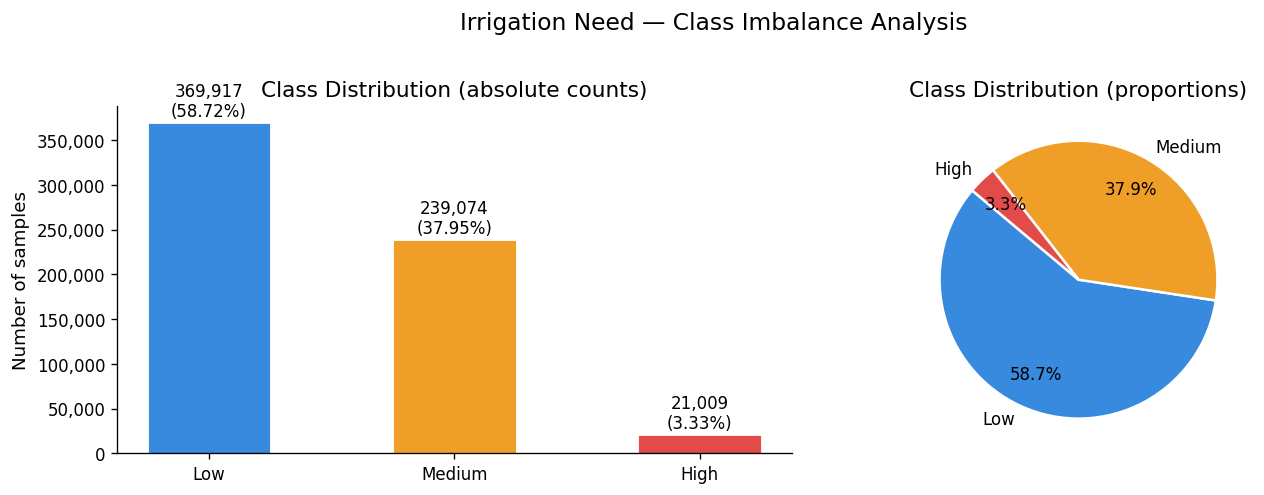


Imbalance ratio (Low:High) = 17:1
⚠️  A naive model predicting always "Low" would have ~58.7% accuracy but 0% recall on High class.


In [6]:
class_counts = df[TARGET].value_counts().reindex(['Low', 'Medium', 'High'])
class_pct = (class_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=[PALETTE[k] for k in class_counts.index],
                   edgecolor='white', linewidth=0.5, width=0.5)
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{count:,}\n({pct}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Class Distribution (absolute counts)')
axes[0].set_ylabel('Number of samples')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=[PALETTE[k] for k in class_counts.index],
            autopct='%1.1f%%', startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (proportions)')

plt.suptitle('Irrigation Need — Class Imbalance Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('deliverable_1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

low = class_counts['Low']
high = class_counts['High']
print(f'\nImbalance ratio (Low:High) = {low//high}:1')
print('⚠️  A naive model predicting always "Low" would have ~'
      f'{class_pct["Low"]:.1f}% accuracy but 0% recall on High class.')

### 3.2 Numerical Feature Distributions

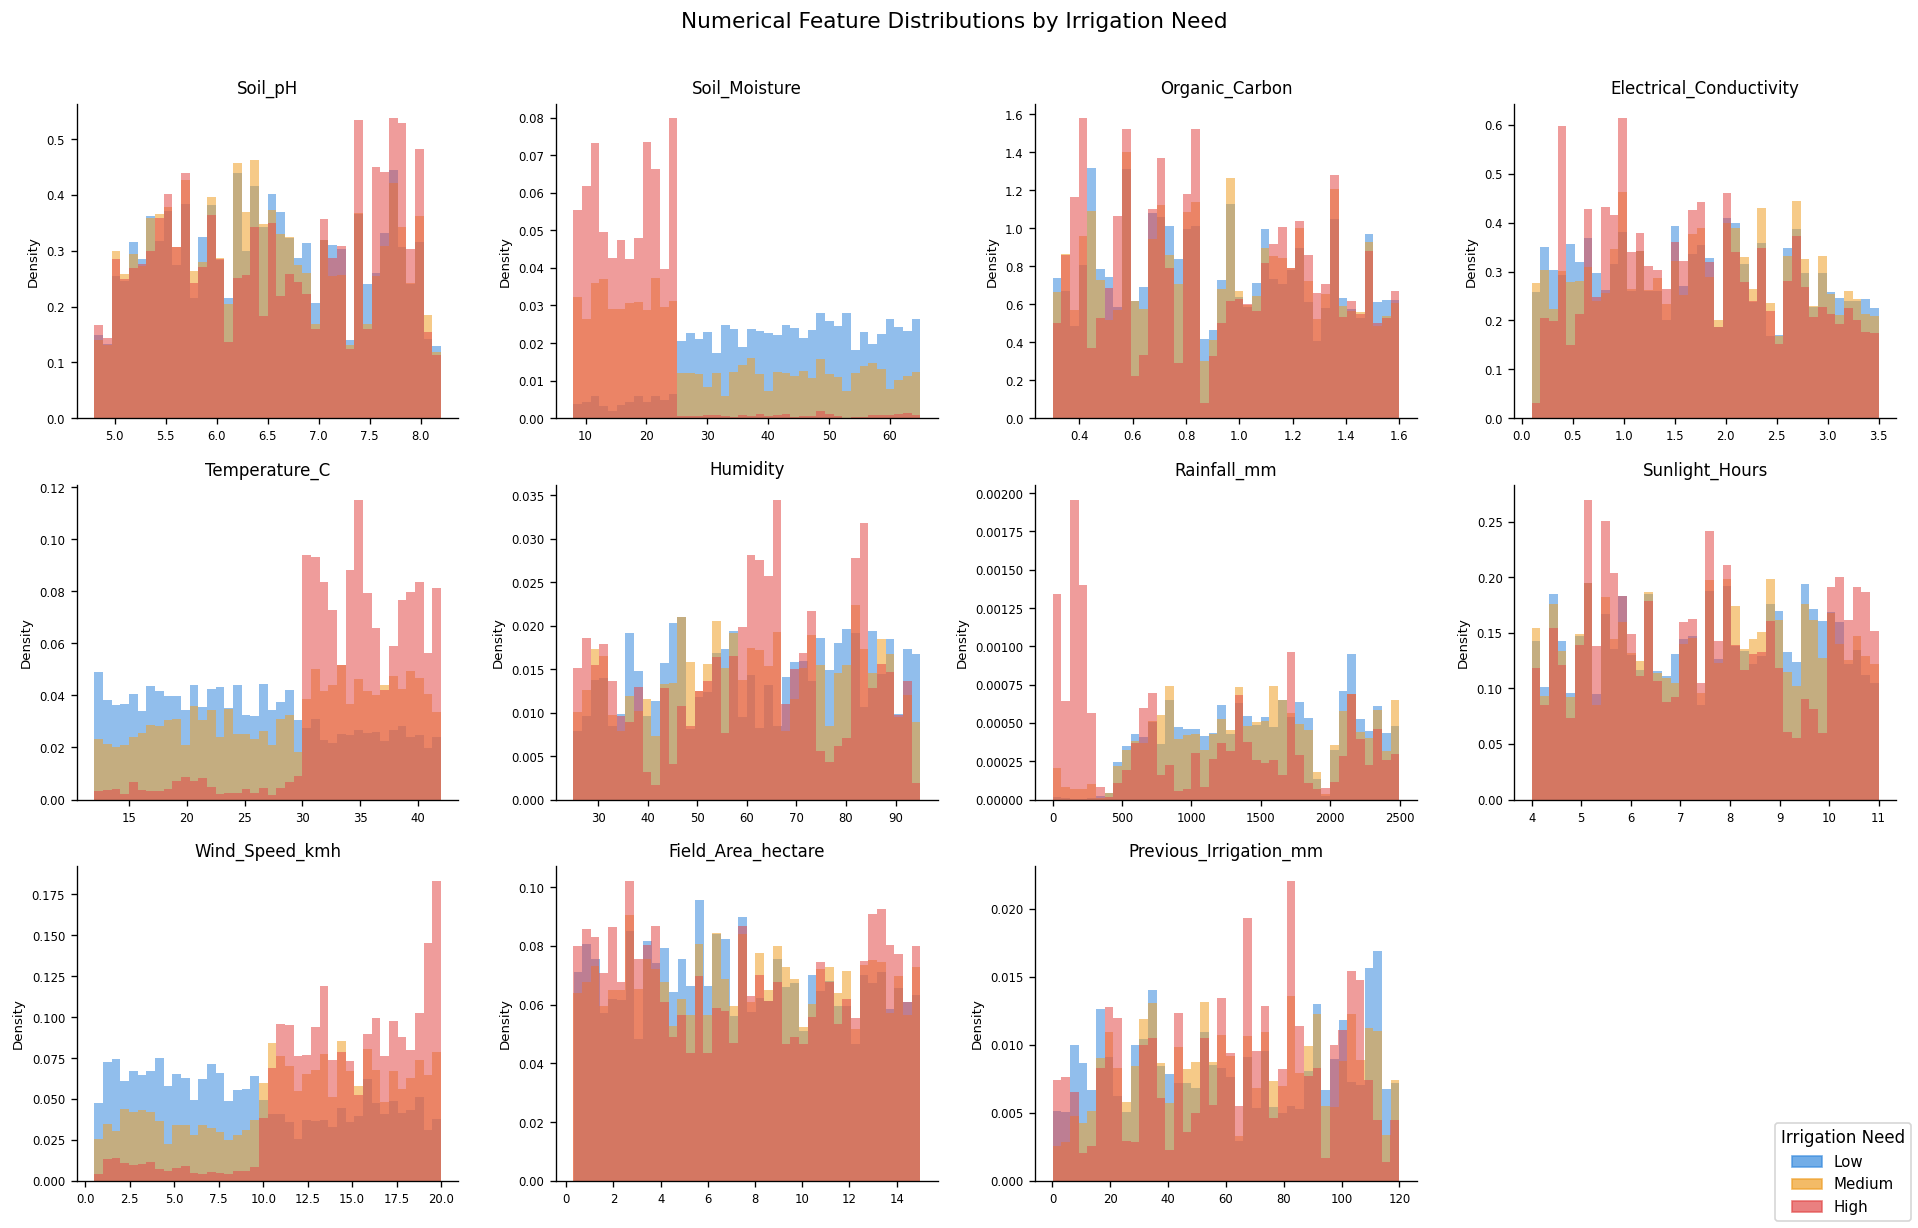

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    for label, color in PALETTE.items():
        subset = df[df[TARGET] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.55, color=color,
                     label=label, density=True, edgecolor='none')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=8)
    axes[i].tick_params(labelsize=7)

# Remove unused axes
for j in range(len(NUM_FEATURES), len(axes)):
    fig.delaxes(axes[j])

handles = [plt.Rectangle((0,0),1,1, color=v, alpha=0.7) for v in PALETTE.values()]
fig.legend(handles, PALETTE.keys(), title='Irrigation Need',
           loc='lower right', fontsize=9)
plt.suptitle('Numerical Feature Distributions by Irrigation Need', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Correlation Matrix

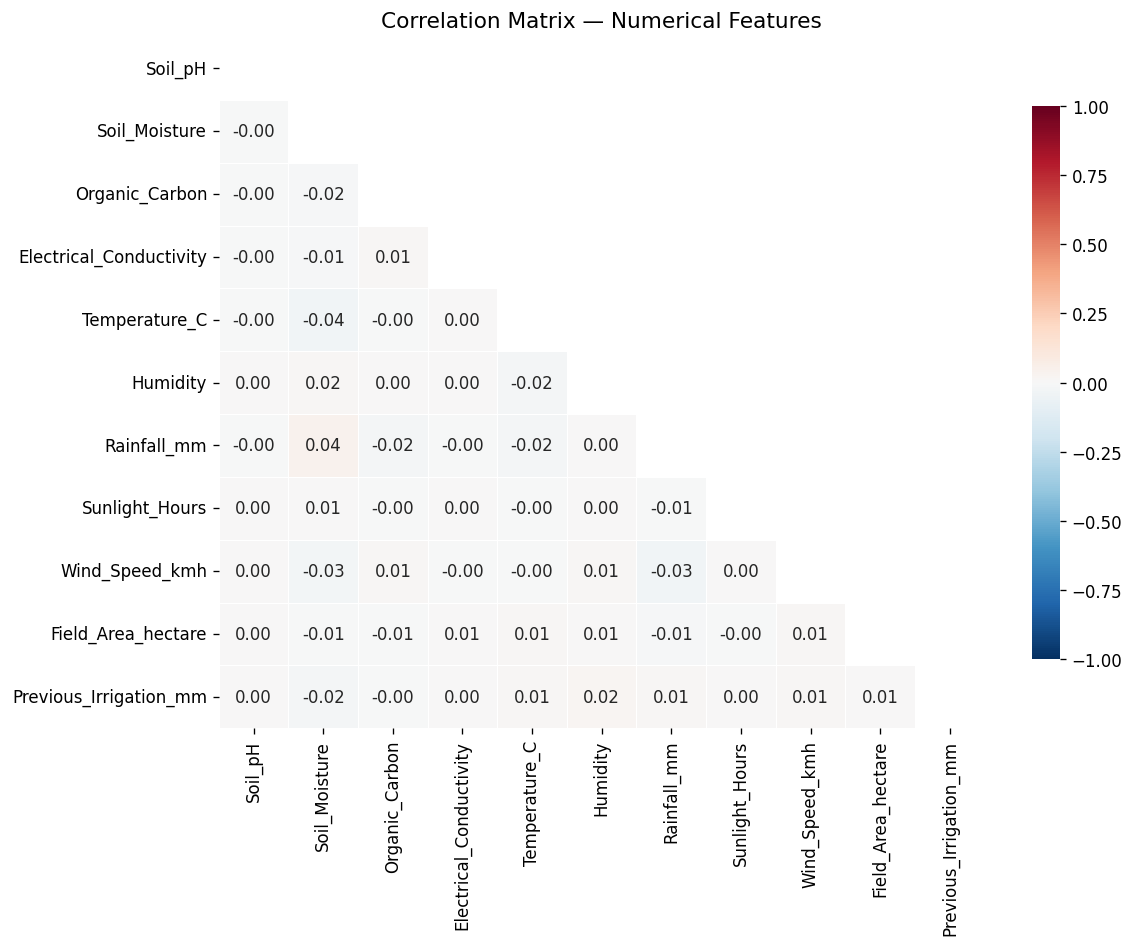

In [8]:
corr = df[NUM_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

### 3.4 Categorical Feature Analysis

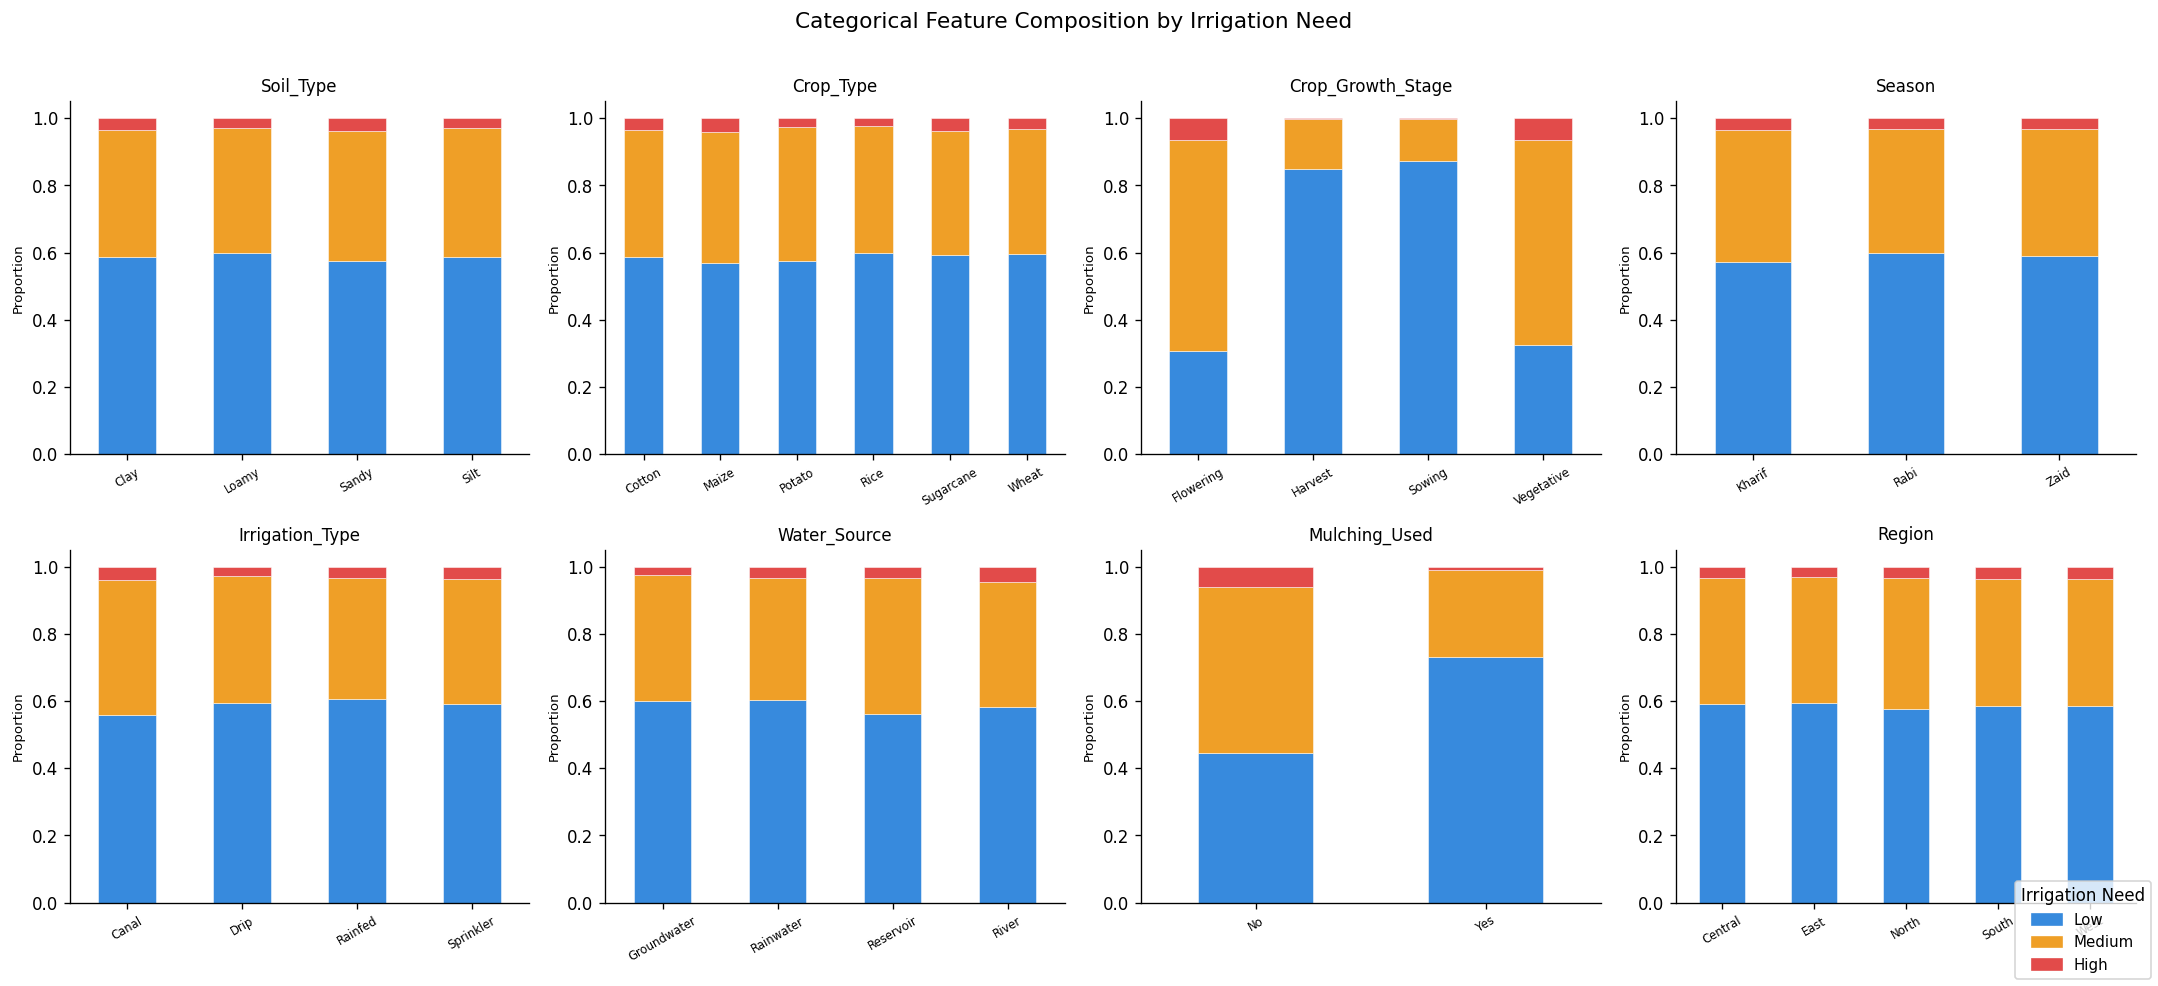

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(CAT_FEATURES):
    ct = pd.crosstab(df[col], df[TARGET], normalize='index')[['Low','Medium','High']]
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=[PALETTE[k] for k in ['Low','Medium','High']],
            edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proportion', fontsize=8)
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)
    axes[i].get_legend().remove()

handles = [plt.Rectangle((0,0),1,1, color=v) for v in PALETTE.values()]
fig.legend(handles, PALETTE.keys(), title='Irrigation Need',
           loc='lower right', fontsize=9)
plt.suptitle('Categorical Feature Composition by Irrigation Need', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Preprocessing & Feature Engineering

In [10]:
# Drop id column
df_clean = df.drop(columns=['id']).copy()

# Encode target: Low=0, Medium=1, High=2 (ordinal — natural order)
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
label_map_inv = {v: k for k, v in label_map.items()}
df_clean[TARGET] = df_clean[TARGET].map(label_map)

print('Target encoding:', label_map)
print('Target value counts after encoding:')
print(df_clean[TARGET].value_counts().sort_index())

Target encoding: {'Low': 0, 'Medium': 1, 'High': 2}
Target value counts after encoding:
Irrigation_Need
0    369917
1    239074
2     21009
Name: count, dtype: int64


In [11]:
# --- Prepare two versions of X ---
# Version A: Label-encoded categoricals (for XGBoost, LightGBM, Logistic Regression)
# Version B: Raw categoricals as strings (for CatBoost)

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# Label encode categoricals for XGB/LGBM
X_encoded = X.copy()
le = LabelEncoder()
for col in CAT_FEATURES:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Cat feature indices for CatBoost
cat_feature_indices = [X.columns.get_loc(c) for c in CAT_FEATURES]

print(f'Feature matrix shape: {X.shape}')
print(f'Categorical feature indices for CatBoost: {cat_feature_indices}')

Feature matrix shape: (630000, 19)
Categorical feature indices for CatBoost: [0, 10, 11, 12, 13, 14, 16, 18]


In [12]:
# Stratified train / val / test split (70 / 15 / 15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.15, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=42)

# Raw (string categoricals) split for CatBoost — same indices
X_raw_temp, X_raw_test = X.iloc[X_temp.index], X.iloc[X_test.index]
X_raw_train, X_raw_val = X.iloc[X_train.index], X.iloc[X_val.index]

print(f'Train size : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   size : {len(X_val):,}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  size : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nClass distribution in train set:')
print(y_train.value_counts().sort_index().rename(label_map_inv))

Train size : 441,000  (70.0%)
Val   size : 94,500  (15.0%)
Test  size : 94,500  (15.0%)

Class distribution in train set:
Irrigation_Need
Low       258941
Medium    167352
High       14707
Name: count, dtype: int64


---
## 5. Handling Class Imbalance

Before SMOTE:
Irrigation_Need
Low       258941
Medium    167352
High       14707
Name: count, dtype: int64

After SMOTE:
Irrigation_Need
Low       258941
Medium    258941
High      258941
Name: count, dtype: int64


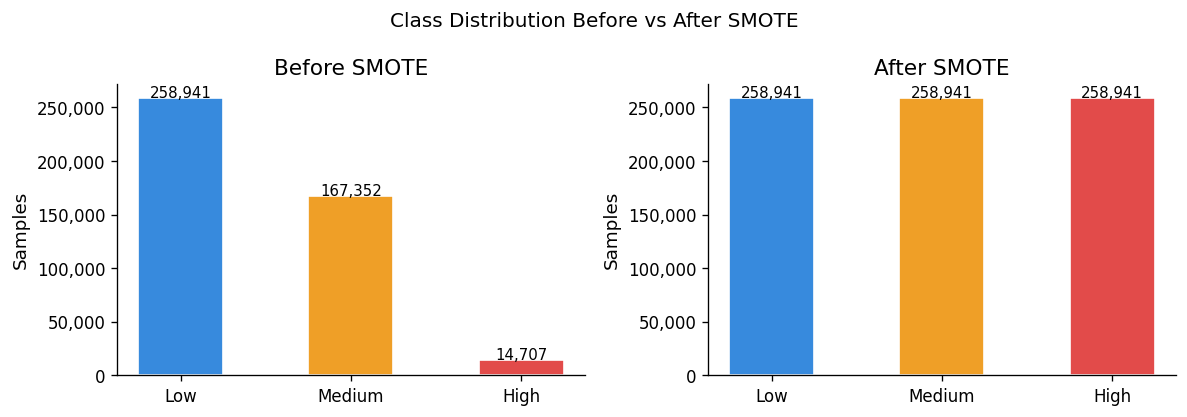

In [13]:
# Apply SMOTE only on training set
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(y_train.value_counts().sort_index().rename(label_map_inv))
print('\nAfter SMOTE:')
print(pd.Series(y_train_smote).value_counts().sort_index().rename(label_map_inv))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, counts, title in zip(
    axes,
    [y_train.value_counts().sort_index(), pd.Series(y_train_smote).value_counts().sort_index()],
    ['Before SMOTE', 'After SMOTE']
):
    labels = [label_map_inv[i] for i in counts.index]
    ax.bar(labels, counts.values,
           color=[PALETTE[l] for l in labels],
           edgecolor='white', width=0.5)
    for j, v in enumerate(counts.values):
        ax.text(j, v + 500, f'{v:,}', ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Samples')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Model Training & Comparison

In [14]:
# Helper: evaluate a model and return metrics
def evaluate(name, y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    acc  = (y_true == y_pred).mean()
    per_class = f1_score(y_true, y_pred, average=None, labels=[0,1,2])
    print(f'\n=== {name} ===')
    print(f'  Accuracy      : {acc:.4f}')
    print(f'  Macro F1      : {macro_f1:.4f}')
    print(f'  QWK           : {qwk:.4f}')
    print(f'  F1 per class  : Low={per_class[0]:.4f} | Medium={per_class[1]:.4f} | High={per_class[2]:.4f}')
    return {'Model': name, 'Accuracy': round(acc,4),
            'Macro F1': round(macro_f1,4), 'QWK': round(qwk,4),
            'F1_Low': round(per_class[0],4),
            'F1_Medium': round(per_class[1],4),
            'F1_High': round(per_class[2],4)}

results = []

### 6.1 Baseline — Logistic Regression

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled   = scaler.transform(X_val)

lr = LogisticRegression(max_iter=1000,
    class_weight='balanced',
    random_state=42)
lr.fit(X_train_scaled, y_train_smote)
y_pred_lr = lr.predict(X_val_scaled)
results.append(evaluate('Logistic Regression (baseline)', y_val, y_pred_lr))


=== Logistic Regression (baseline) ===
  Accuracy      : 0.7154
  Macro F1      : 0.6306
  QWK           : 0.5858
  F1 per class  : Low=0.7980 | Medium=0.6271 | High=0.4668


### 6.2 XGBoost

In [18]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=20,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_val, y_val)],
    verbose=False
)
y_pred_xgb = xgb_model.predict(X_val)
results.append(evaluate('XGBoost', y_val, y_pred_xgb))


=== XGBoost ===
  Accuracy      : 0.9720
  Macro F1      : 0.9363
  QWK           : 0.9557
  F1 per class  : Low=0.9844 | Medium=0.9631 | High=0.8616


### 6.3 LightGBM

In [18]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)]
)
y_pred_lgb = lgb_model.predict(X_val)
results.append(evaluate('LightGBM', y_val, y_pred_lgb))


=== LightGBM ===
  Accuracy      : 0.9710
  Macro F1      : 0.9274
  QWK           : 0.9547
  F1 per class  : Low=0.9857 | Medium=0.9616 | High=0.8348


### 6.4 CatBoost ⭐ (Gold Standard)

In [ ]:
# CatBoost uses raw string categoricals — no encoding needed
train_pool = Pool(X_raw_train, y_train, cat_features=CAT_FEATURES)
val_pool   = Pool(X_raw_val,   y_val,   cat_features=CAT_FEATURES)

cat_model = CatBoostClassifier(
    iterations=100,
    depth=15,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='TotalF1:average=Macro',
    auto_class_weights='Balanced',
    early_stopping_rounds=30,
    random_seed=42,
    verbose=0
)
cat_model.fit(train_pool, eval_set=val_pool)

y_pred_cat = cat_model.predict(X_raw_val).flatten()
results.append(evaluate('CatBoost', y_val, y_pred_cat))

---
## 7. Evaluation & Interpretation

### 7.1 Model Comparison Table — Deliverable 3


=== Model Comparison (Validation Set) ===
                                Accuracy  Macro F1     QWK  F1_Low  F1_Medium  F1_High
Model                                                                                 
Logistic Regression (baseline)    0.7154    0.6306  0.5858  0.7980     0.6271   0.4668
XGBoost                           0.9699    0.9255  0.9529  0.9849     0.9602   0.8314
LightGBM                          0.9710    0.9274  0.9547  0.9857     0.9616   0.8348
CatBoost                          0.9794    0.9509  0.9675  0.9890     0.9726   0.8909


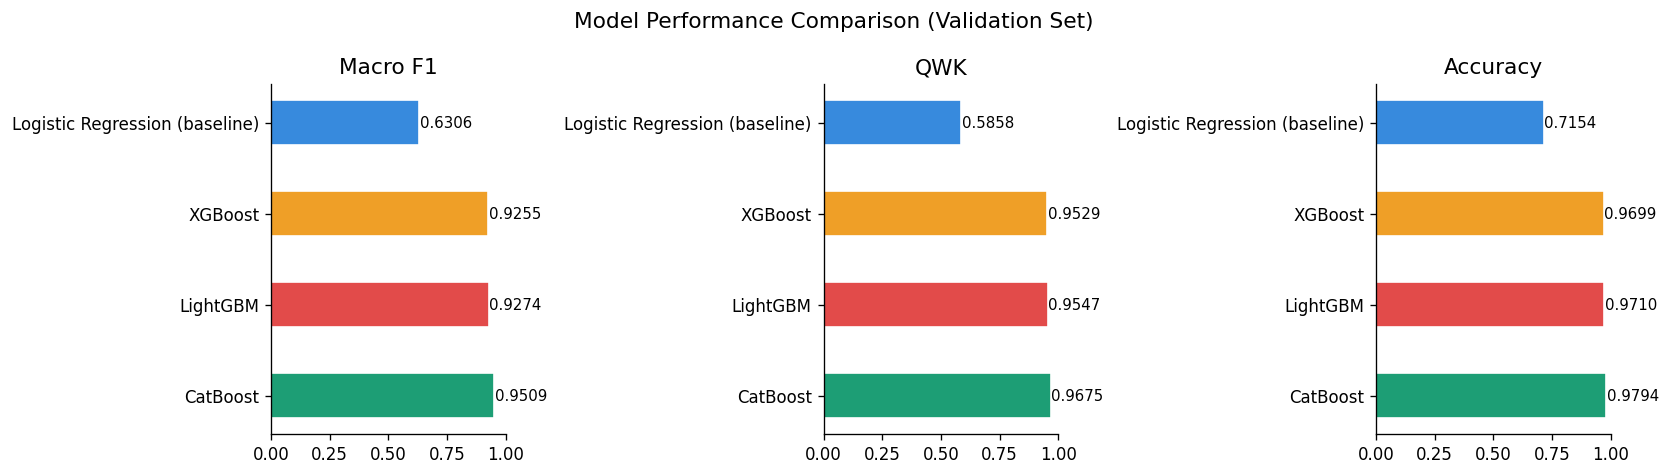

In [20]:
results_df = pd.DataFrame(results).set_index('Model')
print('\n=== Model Comparison (Validation Set) ===')
print(results_df.to_string())

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['Macro F1', 'QWK', 'Accuracy']
colors = ['#378ADD', '#EF9F27', '#E24B4A', '#1D9E75']

for ax, metric in zip(axes, metrics):
    vals = results_df[metric]
    bars = ax.barh(vals.index, vals.values, color=colors[:len(vals)],
                   edgecolor='white', height=0.5)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(metric)
    ax.set_xlim(0, min(1.0, vals.max() * 1.15))
    ax.invert_yaxis()

plt.suptitle('Model Performance Comparison (Validation Set)', fontsize=13)
plt.tight_layout()
plt.savefig('deliverable_3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Best Model on Test Set

In [21]:
# Use best model (typically CatBoost) on held-out test set
test_pool = Pool(X_raw_test, y_test, cat_features=CAT_FEATURES)
y_pred_test = cat_model.predict(X_raw_test).flatten()

print('=== CatBoost — Final Test Set Performance ===')
print(classification_report(y_test, y_pred_test,
                             target_names=['Low', 'Medium', 'High']))

macro_f1_test = f1_score(y_test, y_pred_test, average='macro')
qwk_test = cohen_kappa_score(y_test, y_pred_test, weights='quadratic')
print(f'Macro F1 (test): {macro_f1_test:.4f}')
print(f'QWK      (test): {qwk_test:.4f}')

=== CatBoost — Final Test Set Performance ===
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99     55488
      Medium       0.98      0.96      0.97     35861
        High       0.85      0.93      0.89      3151

    accuracy                           0.98     94500
   macro avg       0.94      0.96      0.95     94500
weighted avg       0.98      0.98      0.98     94500

Macro F1 (test): 0.9505
QWK      (test): 0.9673


### 7.3 Confusion Matrix

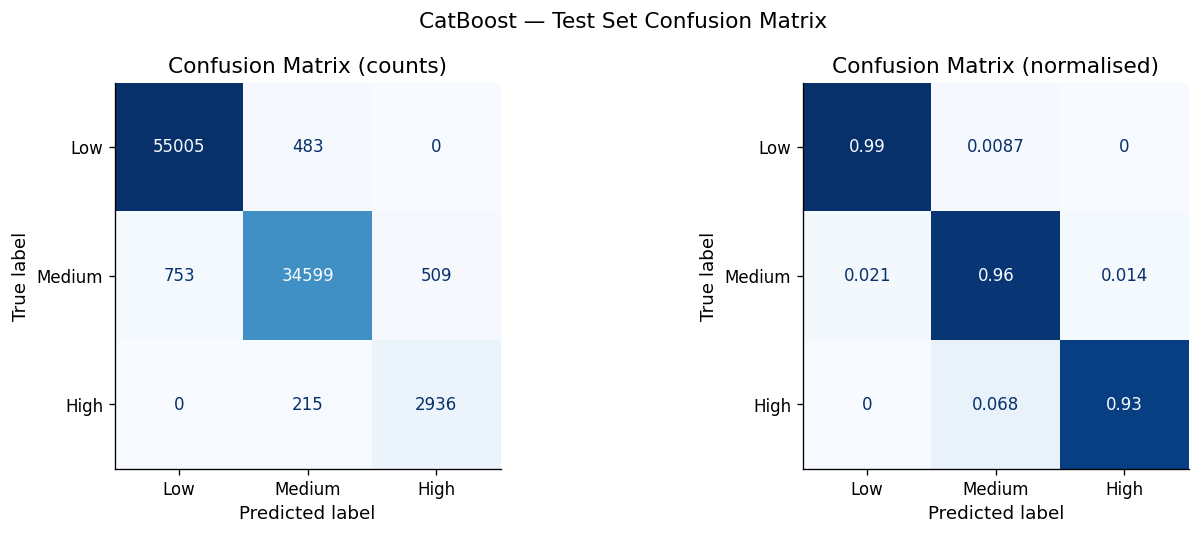

In [22]:
cm = confusion_matrix(y_test, y_pred_test, labels=[0,1,2])
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
class_names = ['Low', 'Medium', 'High']

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
    ['d', '.2f']
):
    disp = ConfusionMatrixDisplay(data, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('CatBoost — Test Set Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### 7.4 Feature Importance — Deliverable 2

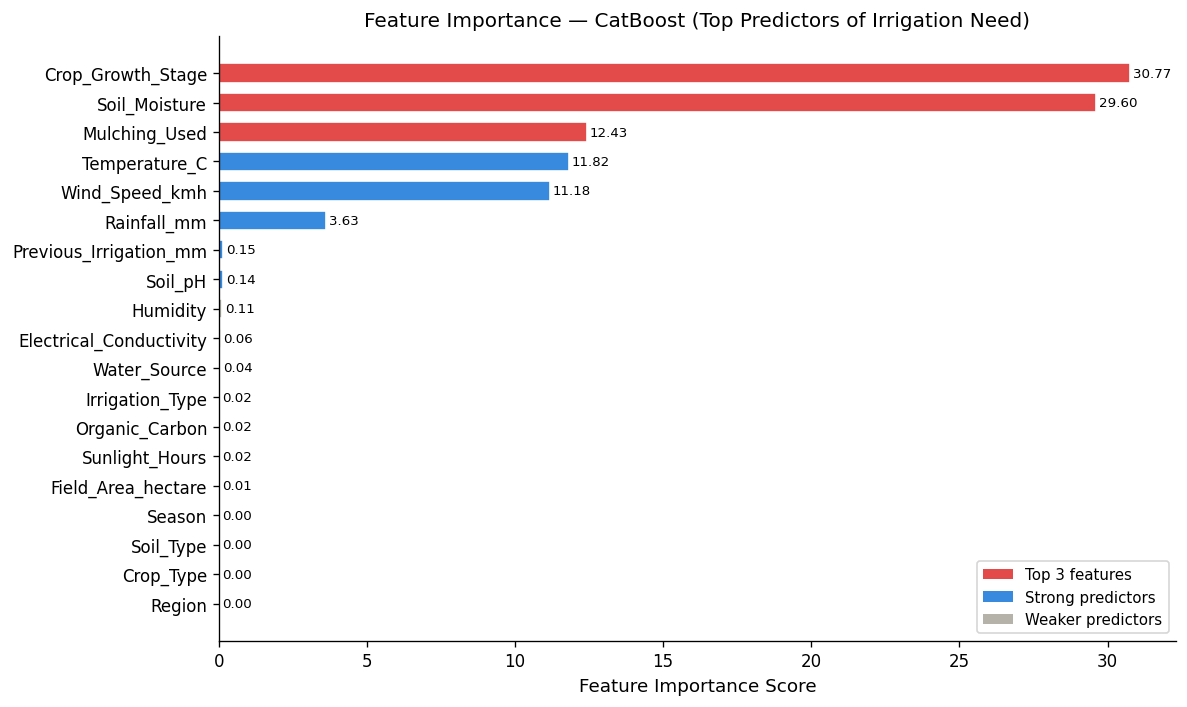

Top 5 features:
Crop_Growth_Stage    30.771913
Soil_Moisture        29.598043
Mulching_Used        12.428057
Temperature_C        11.818018
Wind_Speed_kmh       11.180938
dtype: float64


In [23]:
# Built-in CatBoost feature importance
feat_imp = pd.Series(
    cat_model.get_feature_importance(),
    index=X_raw_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#E24B4A' if i < 3 else '#378ADD' if i < 8 else '#B4B2A9'
             for i in range(len(feat_imp))]
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               color=colors_fi[::-1], edgecolor='white', height=0.65)
for bar, val in zip(bars, feat_imp.values[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Feature Importance — CatBoost (Top Predictors of Irrigation Need)', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='Top 3 features'),
    Patch(facecolor='#378ADD', label='Strong predictors'),
    Patch(facecolor='#B4B2A9', label='Weaker predictors')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('deliverable_2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 features:')
print(feat_imp.head())

---
## 8. Lab Deliverables

### Deliverable 4 — Predictions CSV

In [24]:
# Generate final predictions on test set
test_ids = df.iloc[X_test.index]['id'].values
y_pred_labels = [label_map_inv[p] for p in y_pred_test]

submission = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': y_pred_labels
})
submission.to_csv('deliverable_4_predictions.csv', index=False)
print(f'Predictions saved: {len(submission)} rows')
print(submission['Irrigation_Need'].value_counts())
submission.head(10)

Predictions saved: 94500 rows
Irrigation_Need
Low       55758
Medium    35297
High       3445
Name: count, dtype: int64


,id,Irrigation_Need
0,123629,Low
1,508207,Low
2,369543,Low
3,187506,Low
4,538269,Low
5,605658,Medium
6,197633,Medium
7,607476,Low
8,272623,Low
9,28534,Medium


### Summary — All Deliverables

In [25]:
print('=' * 55)
print('  LAB DELIVERABLES SUMMARY')
print('=' * 55)
print('1. deliverable_1_class_distribution.png')
print('   → Bar + pie chart showing 17:1 class imbalance')
print()
print('2. deliverable_2_feature_importance.png')
print('   → CatBoost feature importance ranked bar chart')
print()
print('3. deliverable_3_model_comparison.png')
print('   → Logistic Regression vs XGB vs LGBM vs CatBoost')
print('   → Metrics: Macro F1, QWK, Accuracy')
print()
print('4. deliverable_4_predictions.csv')
print('   → id + Irrigation_Need for test set')
print('=' * 55)
print(f'Best model  : CatBoost')
print(f'Macro F1    : {macro_f1_test:.4f}')
print(f'QWK         : {qwk_test:.4f}')
print('=' * 55)

  LAB DELIVERABLES SUMMARY
1. deliverable_1_class_distribution.png
   → Bar + pie chart showing 17:1 class imbalance

2. deliverable_2_feature_importance.png
   → CatBoost feature importance ranked bar chart

3. deliverable_3_model_comparison.png
   → Logistic Regression vs XGB vs LGBM vs CatBoost
   → Metrics: Macro F1, QWK, Accuracy

4. deliverable_4_predictions.csv
   → id + Irrigation_Need for test set
Best model  : CatBoost
Macro F1    : 0.9505
QWK         : 0.9673
